In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from math import log2


In [2]:
data = {
    'CustomerID': ['C1', 'C2', 'C3', 'C4', 'C5'],
    'CreditScore': ['High', 'Low', 'Medium', 'Low', 'High'],
    'IncomeLevel': ['High', 'Medium', 'High', 'Low', 'Medium'],
    'LoanAmount': ['Low', 'High', 'Medium', 'Medium', 'Low'],
    'ExistingLoan': ['No', 'Yes', 'No', 'Yes', 'No'],
    'Approved': ['Yes', 'No', 'Yes', 'No', 'Yes']
}

In [3]:
df = pd.DataFrame(data)

In [4]:
def entropy(column):
    values, counts = np.unique(column, return_counts=True)
    total = sum(counts)
    ent = 0
    for count in counts:
        p = count / total
        ent -= p * log2(p)
    return ent

In [5]:
total_entropy = entropy(df['Approved'])
print(f"Total Entropy (Approved): {total_entropy:.3f}")

Total Entropy (Approved): 0.971


In [6]:
def info_gain(df, attribute, target):
    vals, counts = np.unique(df[attribute], return_counts=True)
    weighted_entropy = 0
    for val, count in zip(vals, counts):
        subset = df[df[attribute] == val]
        weighted_entropy += (count / len(df)) * entropy(subset[target])
    return total_entropy - weighted_entropy

In [7]:
for col in ['CreditScore', 'IncomeLevel', 'LoanAmount', 'ExistingLoan']:
    gain = info_gain(df, col, 'Approved')
    print(f"Information Gain ({col}): {gain:.3f}")

Information Gain (CreditScore): 0.971
Information Gain (IncomeLevel): 0.571
Information Gain (LoanAmount): 0.571
Information Gain (ExistingLoan): 0.971


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
df_encoded = df.copy()
le = LabelEncoder()
for col in ['CreditScore', 'IncomeLevel', 'LoanAmount', 'ExistingLoan', 'Approved']:
    df_encoded[col] = le.fit_transform(df[col])

In [10]:
features = ['CreditScore', 'IncomeLevel', 'LoanAmount', 'ExistingLoan']
X = df_encoded[features]
y = df_encoded['Approved']

In [11]:
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

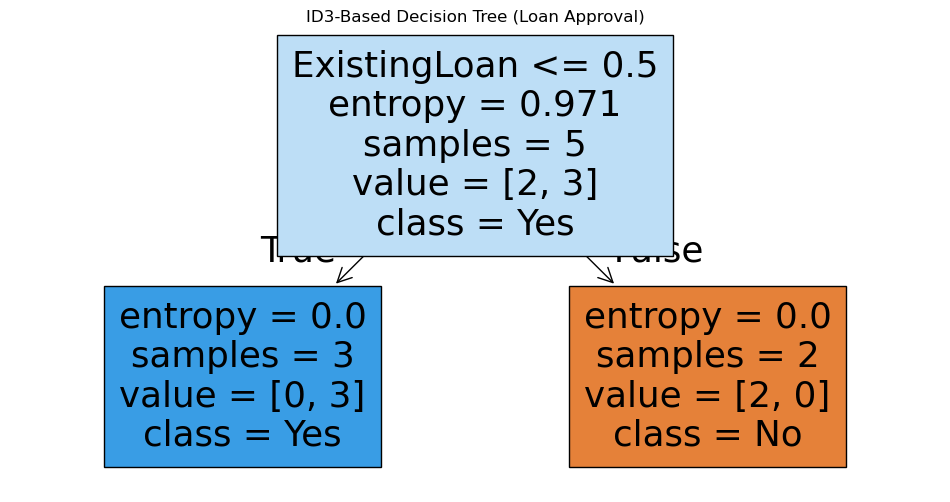

In [12]:
plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=features, class_names=['No', 'Yes'], filled=True)
plt.title("ID3-Based Decision Tree (Loan Approval)")
plt.show()

In [13]:
new_customer = pd.DataFrame({
    'CreditScore': ['Medium'],
    'IncomeLevel': ['High'],
    'LoanAmount': ['Medium'],
    'ExistingLoan': ['No']
})

In [14]:
new_encoded = new_customer.copy()
for col in new_encoded.columns:
    new_encoded[col] = le.fit(df[col]).transform(new_customer[col])

In [15]:
prediction = model.predict(new_encoded)
result = le.inverse_transform(prediction)
print(f"\nPrediction for new customer: Approved = {result[0]}")


Prediction for new customer: Approved = Yes
